## LABORATORIO OPTIMIZACIÓN


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

### Búsqueda Lineal inexacta

In [ ]:
def BLI(d,g,x,f,alpha0=1.0,rho=0.9,c=1e-4):
  alpha=alpha0=1.0
  fx=f(x)
  while f(x+alpha*d)>fx+c*alpha*np.dot(g,d):
    alpha=alpha*rho
  return alpha




In [ ]:
# Definición de la función de Rosenbrock y su respectivo gradiente
def f(x):
    x1, x2 = x
    return 400 * (x2 - x1**2)**2 + (1 - x1)**2

def gf(x):
    x1, x2 = x
    df_dx1 = -1600*x1*(x2 - x1**2) - 2*(1 - x1)
    df_dx2 = 800*(x2 - x1**2)
    return np.array([df_dx1, df_dx2])

In [ ]:
def descenso_grad(f, gf, x0, tol=1e-6, max_iter=50000):
    x = x0.copy()
    fx = f(x)
    X = [x.copy()]
    F = [fx]
    for k in range(max_iter):
        gx = gf(x)
        p=-gx
        ngx = np.linalg.norm(gx)
        if ngx < tol:
            break
        paso = BLI(p,gx,x, f)  # Longitud del paso con Búsqueda lineal inexacta
        x = x - paso * gx
        fx = f(x)
        X.append(x.copy())
        F.append(fx)
    return X, F, k, ngx

In [ ]:
# Parámetros para el problema
x0 = np.array([-2.0, 1.0])  # Punto inicial
tol = 1e-8
X,F,k,ngx=descenso_grad(f,gf,x0,tol)
X=np.array(X)
F=np.array(F)
print('Minimizador aprox: ', X[-1,:])
print('Valor Objetivo: ',F[-1])
print('Iteraciones: ', k)
print('Norma2 grad: ', ngx)

Minimizador aprox:  [1.02150559 1.04344638]
Valor Objetivo:  0.00046278795820626936
Iteraciones:  49999
Norma2 grad:  0.08234807010359703


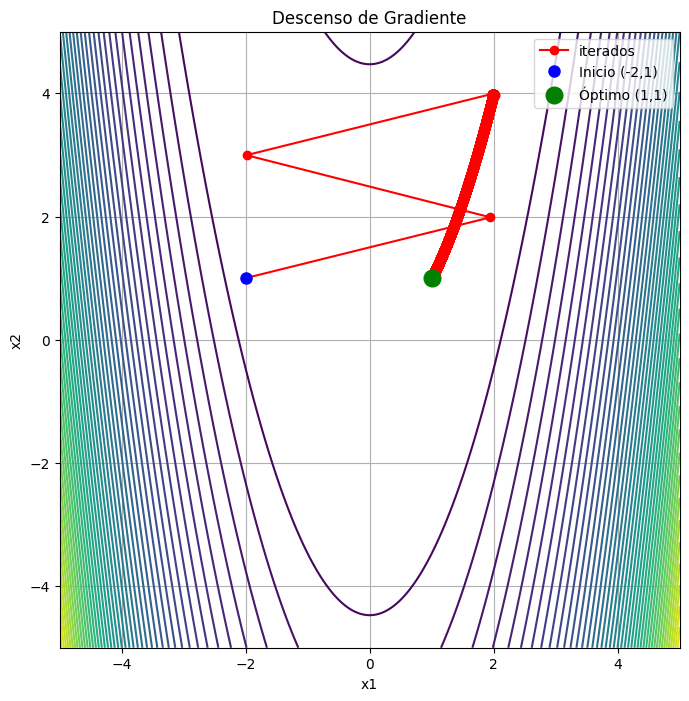

In [ ]:
# Gráfica de Curvas de nivel y aproximaciones
x_opt = np.array([1.0, 1.0])  # Mínimo global de la función de Rosenbrock
x_vals=np.linspace(-5,5,300)
y_vals=np.linspace(-5,5,300)
XX,YY=np.meshgrid(x_vals,y_vals)
ZZ = 400*(YY - XX**2)**2 + (1 - XX)**2
plt.figure(figsize=(8,8))
plt.contour(XX,YY,ZZ,levels=50,cmap='viridis')
plt.plot(X[:,0],X[:,1],'ro-',label='iterados')
plt.plot(x0[0], x0[1], 'bo', markersize=8, label='Inicio (-2,1)')
plt.plot(x_opt[0], x_opt[1], 'go', markersize=12, label='Óptimo (1,1)')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Descenso de Gradiente')
plt.legend()
plt.grid(True)
plt.show()

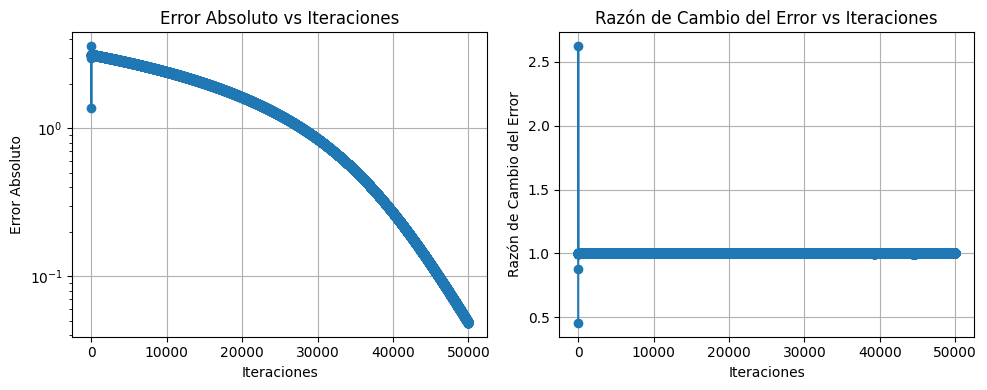

In [ ]:
# Gráfica del Error absoluto y razón de cambio
EAiter = np.linalg.norm(X - x_opt, axis=1)
EAratio=EAiter[1:]/EAiter[:-1] # Razón de cambio del error

plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.yscale('log')
plt.plot(EAiter,'o-')
plt.xlabel('Iteraciones')
plt.ylabel('Error Absoluto')
plt.title('Error Absoluto vs Iteraciones')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(EAratio,'o-')
plt.xlabel('Iteraciones')
plt.ylabel('Razón de Cambio del Error')
plt.title('Razón de Cambio del Error vs Iteraciones')
plt.grid(True)
plt.tight_layout()
plt.show()


### Base de Datos Iris

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [ ]:
X=iris.data.features
Y=iris.data.targets
print(iris.variables)

           name     role         type demographic  \
0  sepal length  Feature   Continuous        None   
1   sepal width  Feature   Continuous        None   
2  petal length  Feature   Continuous        None   
3   petal width  Feature   Continuous        None   
4         class   Target  Categorical        None   

                                         description units missing_values  
0                                               None    cm             no  
1                                               None    cm             no  
2                                               None    cm             no  
3                                               None    cm             no  
4  class of iris plant: Iris Setosa, Iris Versico...  None             no  


       sepal length  sepal width  petal length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
              class
count           150
unique            3
top     Iris-setosa
freq             50


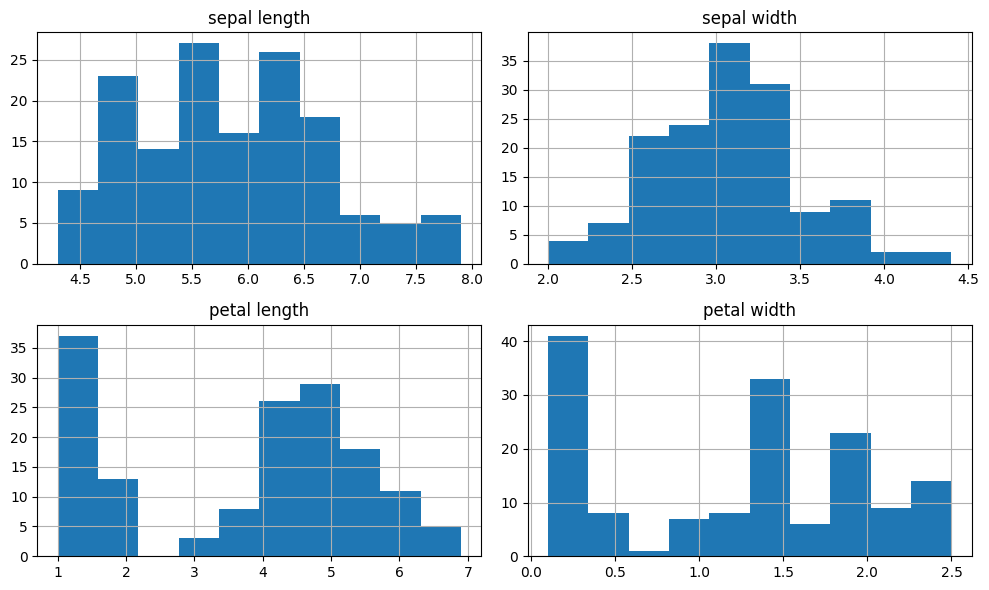

In [ ]:
import matplotlib.pyplot as plt
print(X.describe())
print(Y.describe())
X.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

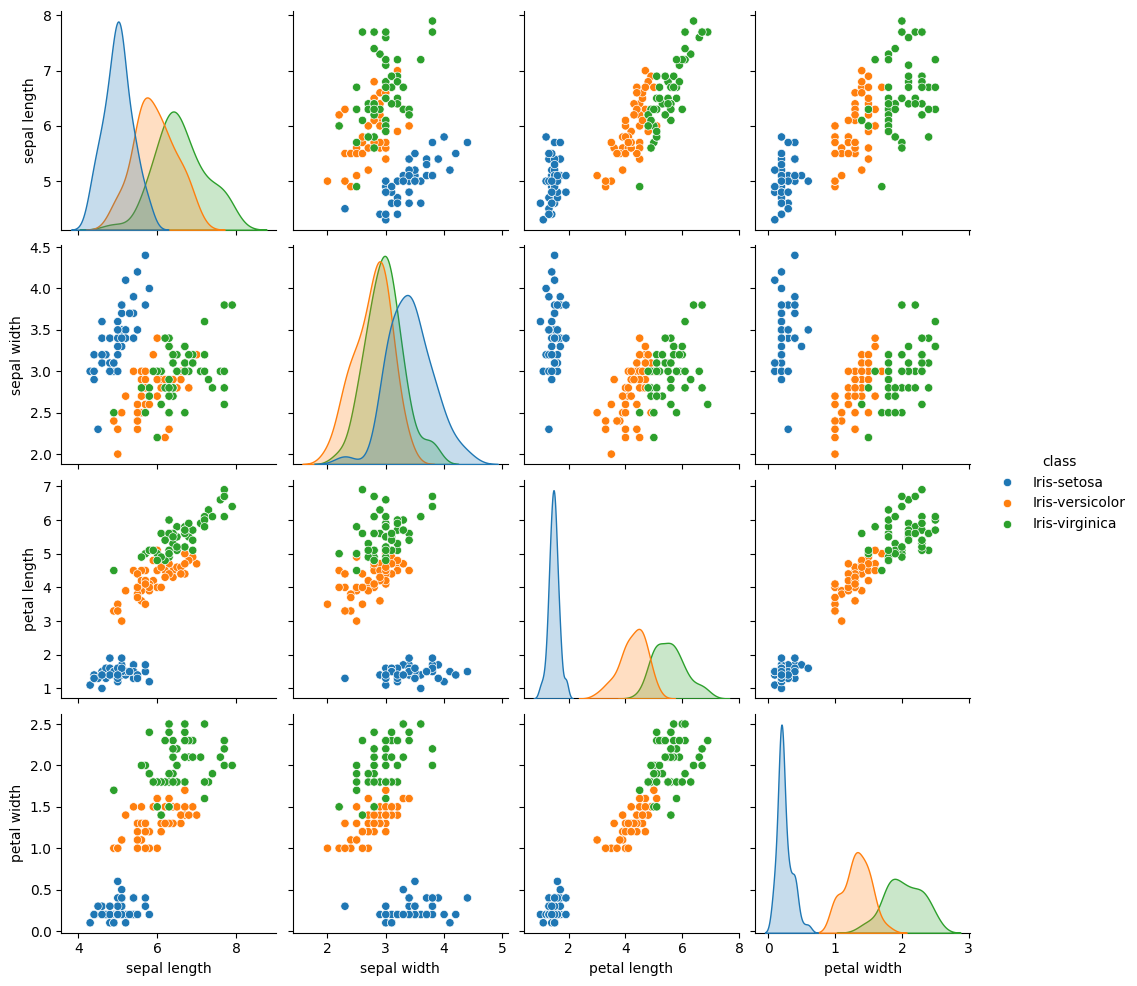

In [ ]:
import seaborn as sns
import pandas as pd
g=sns.pairplot(pd.concat([X,Y],axis=1),hue=Y.columns[0])
g._legend.set_title(Y.columns[0])
plt.show()

In [ ]:
iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets

yT=y.values.ravel()
yT[yT!='Iris-setosa']=1
yT[yT=='Iris-setosa']=0
variables=np.array([0,1])
X2=X.iloc[:,variables].values
XT=np.hstack([np.ones((X.shape[0],1)),X2])


### Función sigmoid

In [ ]:
def sigmoid(z):
  z=np.atleast_1d(z)
  return 1/(1+np.exp(-z))

def fls(w,X,Y):
  p=sigmoid(X@w)
  return float (0.5*np.sum((p-Y)**2))

def f(w):
  return fls(w,XT,yT)

def gradls(w,X,Y):
  p=sigmoid(X@w)
  return np.array(X.T @ ((p-Y)*p*(1-p)),dtype=float)

def gf(w):
  return gradls(w,XT,yT)

In [ ]:
w0=np.zeros(XT.shape[1],dtype=float)
W,F,iter,n2g=descenso_grad(f,gf,w0)
w=W[-1]
p=sigmoid(XT@w)
y_pred=(p>=0.5).astype(int)
pfit=np.mean(y_pred==yT)*100
print('Precisión: ',pfit,'%')
print('Iteraciones: ',iter)
print('Norma2 grad: ',n2g)
print('Pesos sinapticos: ',w)






Precisión:  100.0 %
Iteraciones:  49999
Norma2 grad:  0.00033416320712536976
Pesos sinapticos:  [-62.09719472  24.32451807 -21.75041921]


In [ ]:
print('Valor Objetivo',F[-1])

Valor Objetivo 0.0043989398616378576


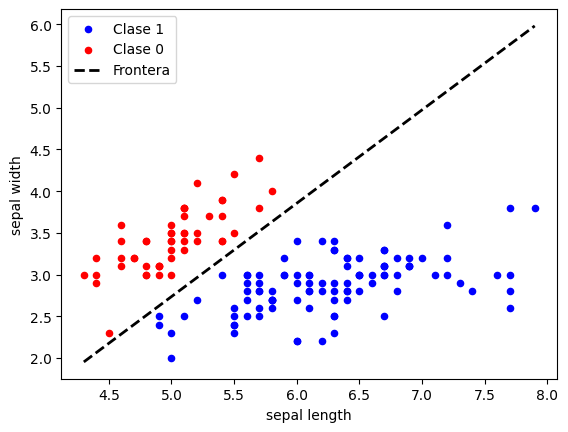

In [ ]:
# Extraer las dos características
x1=X2[:,0]
x2=X2[:,1]
# Gráficar datos
plt.scatter(x1[yT==1],x2[yT==1], c='blue', s=20,label='Clase 1')
plt.scatter(x1[yT==0],x2[yT==0], c='red', s=20,label='Clase 0')
#linea sepradora
#beta=[b,w1,w2]
b=w[0]
w1=w[1]
w2=w[2]

#Generamos una linea en x1
x_line=np.linspace(min(x1),max(x1),100)
y_line=-(b+w1*x_line)/w2

plt.plot(x_line,y_line,'k--',linewidth=2,label='Frontera')

plt.xlabel(X.columns[variables[0]])
plt.ylabel(X.columns[variables[1]])
plt.legend()
plt.show()


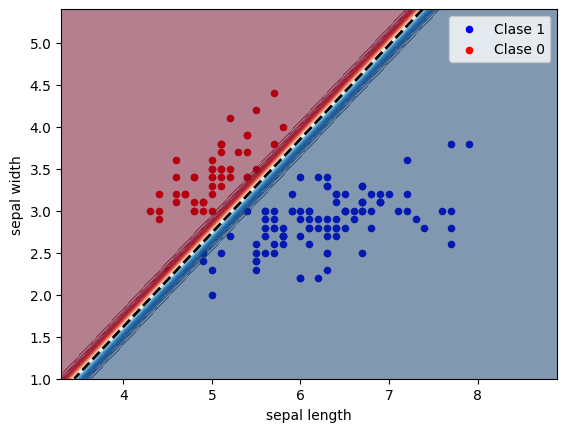

In [ ]:
# Datos de las 2 características
x1=X2[:,0]
x2=X2[:,1]

#Crear malla para curvas de nivel
xx,yy=np.meshgrid(np.linspace(x1.min()-1,x1.max()+1,300),
                  np.linspace(x2.min()-1,x2.max()+1,300))
zz=sigmoid(w[0]+w[1]*xx+w[2]*yy)

#Gráficar datos
plt.scatter(x1[yT==1],x2[yT==1],c='blue',s=20,label='Clase 1')
plt.scatter(x1[yT==0],x2[yT==0],c='red',s=20,label='Clase 0')
#Curvas de niveldel sigmoide
plt.contourf(xx,yy,zz,levels=100,cmap='RdBu',alpha=0.5)
plt.contour(xx,yy,zz,levels=[0.5],colors='black',linewidths=2,linestyles='--')
#plt.colorbar(label='Probabilidad clase 1')
plt.xlabel(X.columns[variables[0]])
plt.ylabel(X.columns[variables[1]])
plt.legend()
plt.show()